<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Association_Rule_Mining_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 6: Association Rule Mining**

This script illustrates some of the functions in arules and arulesViz. It also uses the "vote" data, which is the subject of Homework 3. You should use it as your starting point for the homework.

In [ ]:
pkgs <- c("arules", "arulesViz")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [ ]:
library(arules)
library(arulesViz)

vote = read.csv("vote.csv")

## **Learning and Summarizing Rules**

The apriori() function uses the apriori algorithm to learn association rules. The only required input is the data set and the default minimum support and confidence will be used:

In [ ]:
rules = apriori(vote)

Warning message:
“Column(s) 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17 not logical or factor. Applying default discretization (see '? discretizeDF').”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5     0.1      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 43 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[50 item(s), 435 transaction(s)] done [0.00s].
sorting and recoding items ... [36 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 7 8 9 10

Warning message in apriori(vote):
“Mining stopped (maxlen reached). Only patterns up to a length of 10 returned!”


 done [0.12s].
writing ... [482817 rule(s)] done [0.12s].
creating S4 object  ... done [0.17s].


We get a warning because the possible patterns (number of items in a rule) exceeds the default maximum of 10 items.

We can change it if we like:

In [ ]:
rules = apriori(vote,
                parameter=list(maxlen = 15))

Warning message:
“Column(s) 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17 not logical or factor. Applying default discretization (see '? discretizeDF').”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5     0.1      1
 maxlen target  ext
     15  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 43 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[50 item(s), 435 transaction(s)] done [0.00s].
sorting and recoding items ... [36 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 7 8 9 10 11 12 13 14 done [0.14s].
writing ... [492081 rule(s)] done [0.10s].
creating S4 object  ... done [0.15s].


The parameter object is also where we can change the default minimum support (= 0.1) and the default minimum confidence (= 0.8), which we will do later.

 We can look at a summary of the rules found.

In [ ]:
summary(rules)

set of 492081 rules

rule length distribution (lhs + rhs):sizes
     2      3      4      5      6      7      8      9     10     11     12 
   152   2514  15618  48687  94391 122493 107539  64683  26740   7593   1463 
    13     14 
   194     14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   6.000   7.000   7.217   8.000  14.000 

summary of quality measures:
    support         confidence        coverage           lift      
 Min.   :0.1011   Min.   :0.8000   Min.   :0.1011   Min.   :1.279  
 1st Qu.:0.1103   1st Qu.:0.9000   1st Qu.:0.1172   1st Qu.:1.689  
 Median :0.1264   Median :0.9444   Median :0.1356   Median :1.900  
 Mean   :0.1452   Mean   :0.9345   Mean   :0.1559   Mean   :1.941  
 3rd Qu.:0.1747   3rd Qu.:0.9785   3rd Qu.:0.1862   3rd Qu.:2.203  
 Max.   :0.5632   Max.   :1.0000   Max.   :0.6138   Max.   :2.756  
     count       
 Min.   : 44.00  
 1st Qu.: 48.00  
 Median : 55.00  
 Mean   : 63.15  
 3rd Qu.: 76.00  
 Max.   :245.00  

mining info:
 data

 The function quality() provides the support, confidence and lift for the set of rules (along with counts); that is, a more direct way to look at the quality part of the summary.

In [ ]:
quality(rules)
max(quality(rules)$support)
max(quality(rules)$confidence)
max(quality(rules)$lift)

,support,confidence,coverage,lift,count
,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,0.1149425,0.8064516,0.1425287,2.088134,50
2,0.1310345,0.9193548,0.1425287,2.338710,57
3,0.1264368,0.8870968,0.1425287,2.180153,55
4,0.1356322,0.9516129,0.1425287,2.325571,59
5,0.1356322,0.9516129,0.1425287,2.274459,59
6,0.1333333,0.9354839,0.1425287,1.975415,58
7,0.1287356,0.9032258,0.1425287,1.879920,56
8,0.1356322,0.9516129,0.1425287,1.952602,59
9,0.1264368,0.8870968,0.1425287,1.656168,55


[1] 0.5632184

[1] 1

[1] 2.755848

The inspect() function allows us to output specific rules, e.g. rules 1-15

In [ ]:
inspect(rules[1:15])

     lhs                                           rhs                                     support confidence  coverage     lift count
[1]  {export.administration.act.south.africa=n} => {Class=republican}                    0.1149425  0.8064516 0.1425287 2.088134    50
[2]  {export.administration.act.south.africa=n} => {adoption.of.the.budget.resolution=n} 0.1310345  0.9193548 0.1425287 2.338710    57
[3]  {export.administration.act.south.africa=n} => {physician.fee.freeze=y}              0.1264368  0.8870968 0.1425287 2.180153    55
[4]  {export.administration.act.south.africa=n} => {aid.to.nicaraguan.contras=n}         0.1356322  0.9516129 0.1425287 2.325571    59
[5]  {export.administration.act.south.africa=n} => {anti.satellite.test.ban=n}           0.1356322  0.9516129 0.1425287 2.274459    59
[6]  {export.administration.act.south.africa=n} => {mx.missile=n}                        0.1333333  0.9354839 0.1425287 1.975415    58
[7]  {export.administration.act.south.africa=n} => {sup

## **Pruning Rules**

Clearly there are way too many rules (this is always the case with association rule mining). We can look at a subset of rules that is restricted by some measure of the quality as follows:

In [ ]:
good_rules = rules[quality(rules)$confidence>0.9]
length(good_rules)

[1] 368087

This is still a lot of rules! Let’s restrict them further:

In [ ]:
good_rules = good_rules[quality(good_rules)$support>0.35]
length(good_rules)

[1] 505

Still too many! Let’s limit to the higher lift rules too:

In [ ]:
good_rules = good_rules[quality(good_rules)$lift>1.8]
length(good_rules)

[1] 80

Appropriate cutoff values (or at least first guesses) can be found by looking at the summary of the rules, but I  expect you to put a bit more thought into those cutoff values.


## **Plotting**

 We are now down to only 80 rules, which is still a large number, but with a more reasonable subset of rules, we can start creating plots.

By default we get a scatter plot of rules as a function of support and confidence with lift as the color.

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



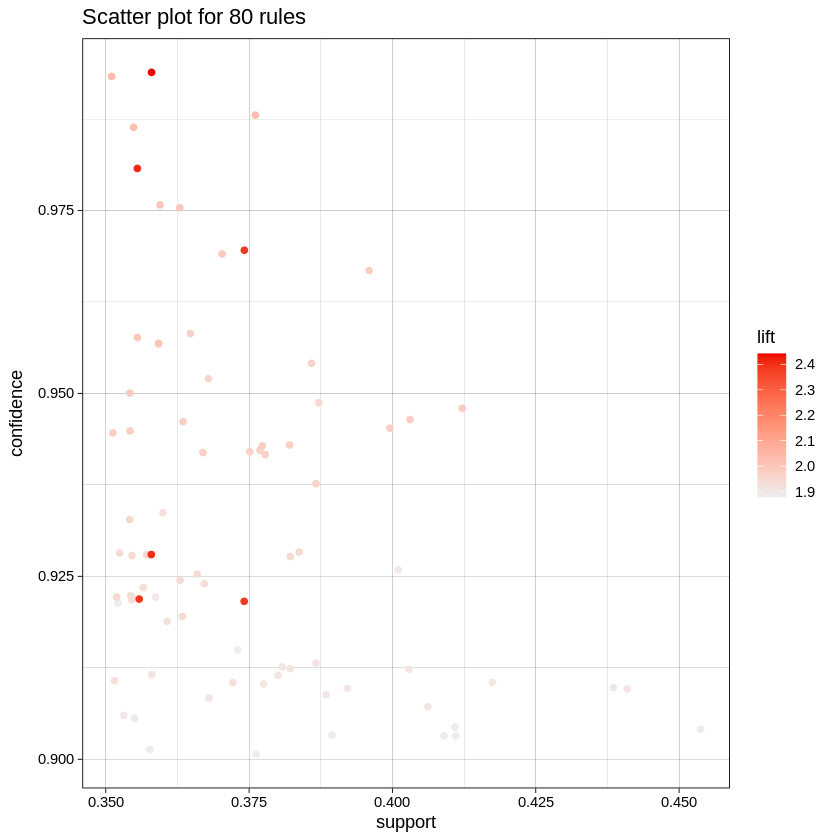

In [ ]:
plot(good_rules)

We can change how support/confidence/lift are used:

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



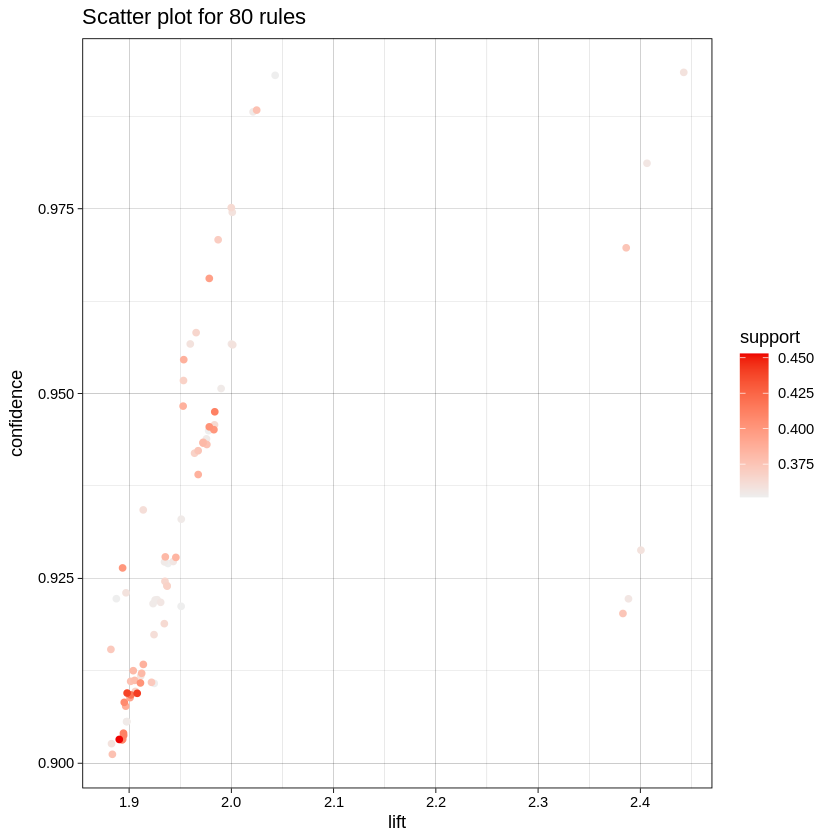

In [ ]:
plot(good_rules, measure="lift",
     shading = "support")

This is harldy an improvement, but it is something we can change!

There are actually quite a few interesting types and those are specified in the "method". Let's try a couple:

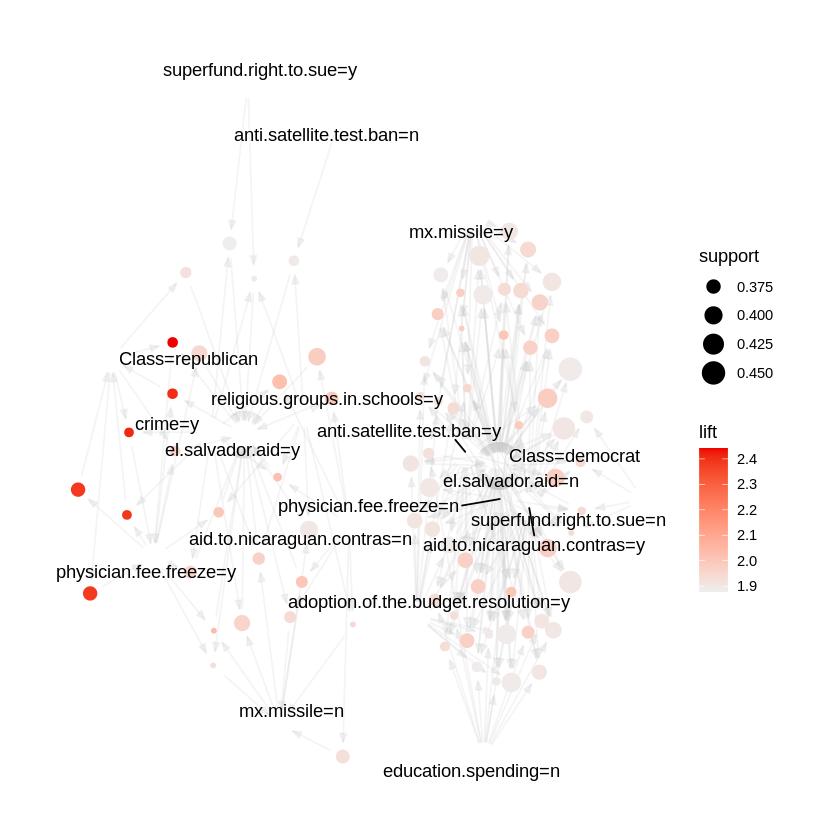

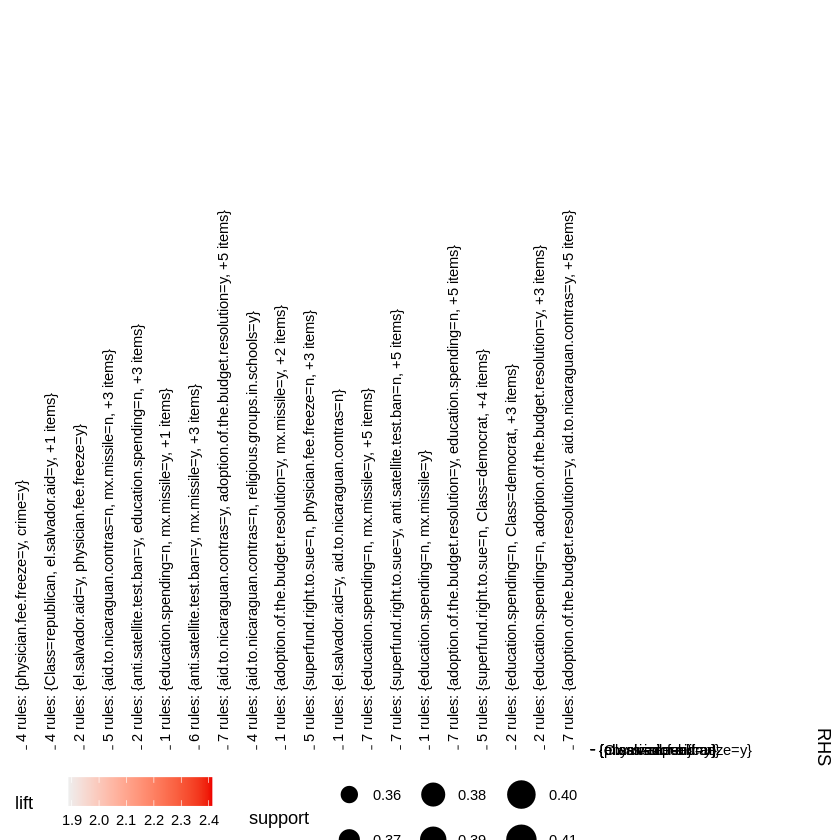

In [ ]:
plot(good_rules, method="graph")
plot(good_rules, method="grouped")

## **Restricting the Consequent**

We also often want to look specifically at a set of rules based on one or more specific components. Here, for example, we might want to look at all rules that have “democrat” in the consequent (rhs = right-hand-side).

 We’ll therefore go back to the original “rules” and restrict them accordingly:

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



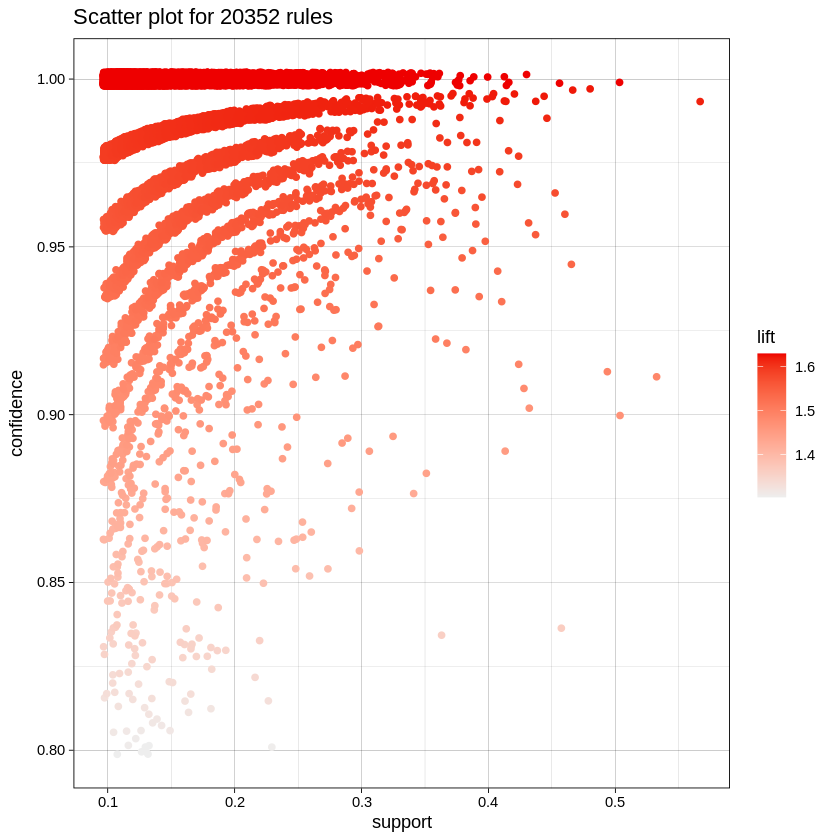

In [ ]:
Dem_rules = subset(rules,
                   subset = rhs %in% "Class=democrat")
plot(Dem_rules)

We got over 20 thousand rules, so clearly me might want to restrict them as above. But we can also, for example, look at the 10 best rules of this type, where we define “best” as having the highest lift (also try confidence and support):

In [ ]:
inspect(head(Dem_rules, n=10, by = "lift"))

     lhs                                           rhs                support confidence  coverage     lift count
[1]  {physician.fee.freeze=n,                                                                                    
      export.administration.act.south.africa=?} => {Class=democrat} 0.1724138          1 0.1724138 1.629213    75
[2]  {physician.fee.freeze=n,                                                                                    
      synfuels.corporation.cutback=y}           => {Class=democrat} 0.2597701          1 0.2597701 1.629213   113
[3]  {religious.groups.in.schools=n,                                                                             
      crime=n}                                  => {Class=democrat} 0.2689655          1 0.2689655 1.629213   117
[4]  {crime=n,                                                                                                   
      duty.free.exports=y}                      => {Class=democrat} 0.2804598          1

## **Learning What You Want: parameter and appearance**

You can also "pre-prune" rules as they are generated. This is more useful if you have done enough analysis so that you have a good idea of what you want.

Warning message:
“Column(s) 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17 not logical or factor. Applying default discretization (see '? discretizeDF').”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5     0.4      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 174 

set item appearances ...[1 item(s)] done [0.00s].
set transactions ...[50 item(s), 435 transaction(s)] done [0.00s].
sorting and recoding items ... [27 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 done [0.00s].
writing ... [38 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


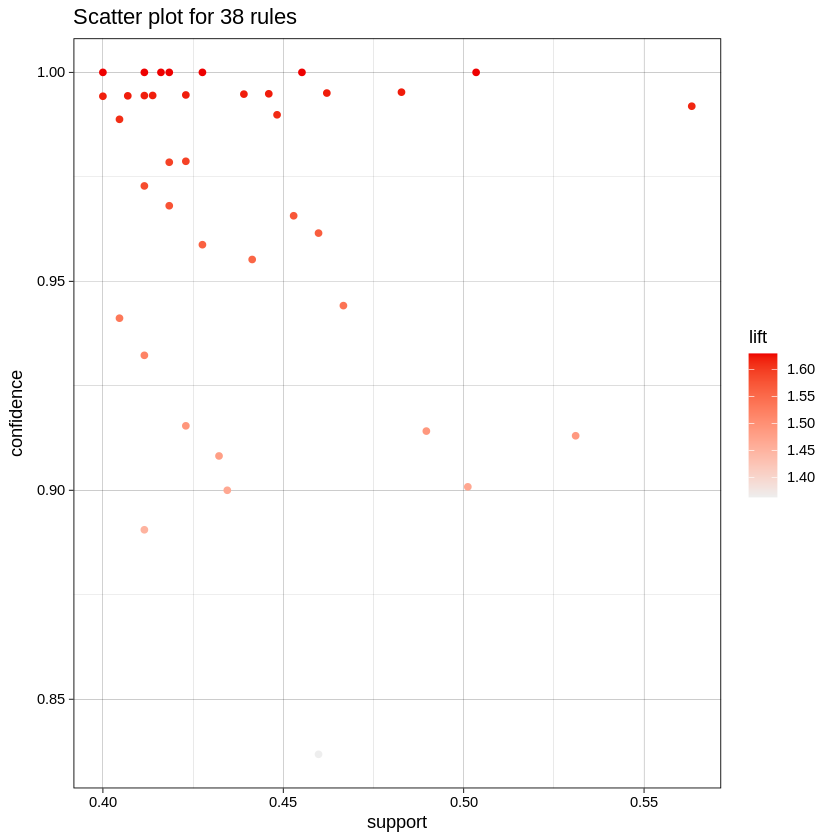

In [ ]:
rules = apriori(vote,
                 parameter = list(supp = 0.4,
                                  conf = 0.8,
                                  target = "rules"),
                appearance = list(rhs = "Class=democrat"))
plot(rules)

## **The APP**

You can interactively explore rules using a Shiny R app.

In [ ]:
pkgs <- c("shiny")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [ ]:
library(shiny)

In [ ]:
ruleExplorer(rules)

ruleExplorer started.


Listening on http://127.0.0.1:4070



You can also create an interactive table that can be saved as a web page (html document)

In [ ]:
inspectDT(rules)

More reading:
 https://journal.r-project.org/archive/2017/RJ-2017-047/RJ-2017-047.pdf